In [137]:
import numpy as np
import znnl as nl

import pandas as pd

from flax import linen as nn
import optax

import matplotlib.pyplot as plt
from neural_tangents import stax

import h5py as hf
from scipy.stats import pearsonr

from rich.progress import track

import seaborn as sns

## Download the data

In [70]:
class AbaloneData(nl.data.DataGenerator):
    """
    Generator for the Abalone data-set.
    
    Notes
    -----
    
    URL: http://archive.ics.uci.edu/static/public/1/abalone.zip
    """
    
    def __init__(self, data_file: str = "abalone.data"):
        """
        Build the data-set.
        """
        self.data_file = data_file
        self.columns = [
            "Sex",
            "Length", 
            "Diameter", 
            "Height", 
            "Whole weight", 
            "Shucked weight", 
            "Viscera weight", 
            "Shell weight", 
            "Rings"
        ]
        
        # Collect the processed data
        processed_data = self._process_raw_data()
        
        # Create the data-sets
        train_ds = processed_data.sample(frac=0.8, random_state=0)
        train_labels = train_ds.pop("Rings")
        
        test_ds = processed_data.drop(train_ds.index)
        test_labels = test_ds.pop("Rings")
        
        self.train_ds = {
            "inputs": train_ds.to_numpy(), 
            "targets": train_labels.to_numpy().reshape(-1, 1)
        }
        self.test_ds = {
            "inputs": test_ds.to_numpy(), 
            "targets": test_labels.to_numpy().reshape(-1, 1)
        }
        
        self.data_pool = self.train_ds["inputs"]
        
        
    def _process_raw_data(self):
        """
        Process the raw data
        """
        # Process the raw data.
        raw_data = pd.read_csv(
            self.data_file, names=self.columns, na_values='?', comment='#',
                          sep=',', skipinitialspace=True
        )
        raw_data.dropna()
        
        # encode the sex data
        raw_data = pd.get_dummies(raw_data, columns=['Sex'], prefix='', prefix_sep='')
        # Normalize
        raw_data = (raw_data - raw_data.mean()) / raw_data.std()

        return raw_data
        
        

In [71]:
generator = AbaloneData()

In [123]:
network = stax.serial(
        stax.Dense(256),
        stax.Relu(),
        stax.Dense(256),
        stax.Relu(),
        stax.Dense(1),
    )

model = nl.models.NTModel(
                nt_module=network,
                optimizer=optimizer,
                input_shape=(1, 10),
                batch_size=5
        )

## Eigenvalue distributions

In [164]:
ds_sizes = [2000]
ds_ensembles = 5
model_ensembles = 5
# eig_data = {item: [] for item in ds_sizes}
# trace_data = {item: [] for item in ds_sizes}

eig_data[2000] = []
trace_data[2000] = []

for _ in track(range(model_ensembles)):
    model = nl.models.NTModel(
                nt_module=network,
                optimizer=optimizer,
                input_shape=(1, 10),
                batch_size=5
        )
    for ds_size in ds_sizes:
        for _ in range(model_ensembles):
            indices = np.random.randint(
                0, generator.train_ds["inputs"].shape[0] - 1, size=ds_size
            )
            ds = np.take(generator.train_ds["inputs"], indices, axis=0)
            
            matrix = model.compute_ntk(ds)["empirical"]
            
            eigs, _ = np.linalg.eigh(matrix)
            trace = np.trace(matrix)
            
            eig_data[ds_size].append(eigs)
            trace_data[ds_size].append(trace)

Output()

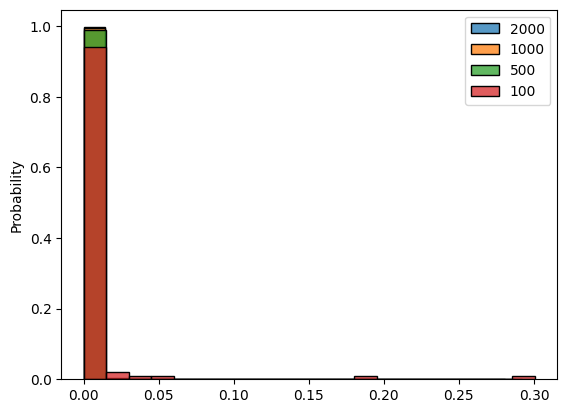

In [201]:
test = eig_data[500]

# for item in test[0]:
sns.histplot(x=np.mean(eig_data[2000], axis=0) / 2000, bins=20, stat="probability", discrete=False, label=2000)
sns.histplot(x=np.mean(eig_data[1000], axis=0) / 1000, bins=20, stat="probability", discrete=False, label=1000)
sns.histplot(x=np.mean(eig_data[500], axis=0) / 500, bins=20, stat="probability", discrete=False, label=500)
sns.histplot(x=np.mean(eig_data[100], axis=0) / 100, bins=20, stat="probability", discrete=False, label=100)

# sns.kdeplot(np.mean(eig_data[2000], axis=0), label=2000)
# sns.kdeplot(np.mean(eig_data[1000], axis=0), label=1000)
# sns.kdeplot(np.mean(eig_data[500], axis=0), label=500)
# sns.kdeplot(np.mean(eig_data[100], axis=0), label=100)


plt.legend()
# plt.xlim(-10, 50)
# plt.yscale("log")
plt.show()

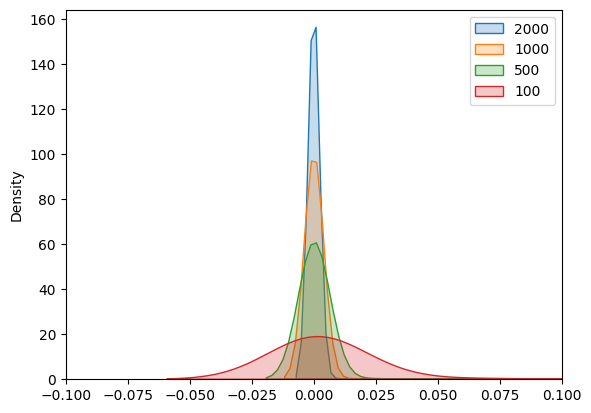

In [208]:

huge = np.mean([item / item.sum() for item in eig_data[2000]], axis=0)
large = np.mean([item / item.sum() for item in eig_data[1000]], axis=0)
medium = np.mean([item / item.sum() for item in eig_data[500]], axis=0)
small = np.mean([item / item.sum() for item in eig_data[100]], axis=0)


sns.kdeplot(huge, label=2000, fill=True)
sns.kdeplot(large, label=1000, fill=True)
sns.kdeplot(medium, label=500, fill=True)
sns.kdeplot(small, label=100, fill=True)


plt.legend()
plt.xlim(-0.1, 0.1)
plt.show()

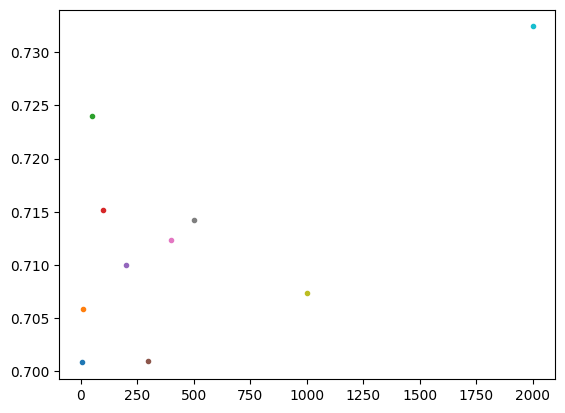

In [209]:
for item in trace_data:
    plt.plot(item, np.mean(trace_data[item]) / item, '.')